## 📘 Project A – Arabic–English News NLP Pipeline  
### Deliverable 2: Data Collection & Exploratory Data Analysis (EDA)

---

### 🧾 Dataset Description
We used two news datasets:
- **Arabic dataset:** Collected from Kaggle Arabic News Dataset.  
- **English dataset:** Collected from Malaysia biggest online news collection on Kaggle.  
Both contain short news articles with categories such as **Politics**, **Business**, **Sports**, and **Technology**.

Each record includes:
- `text`: the news article content  
- `category`: the topic label  
- `language`: manually added field (Arabic or English)

Total size after merging: around **2,000 articles** (balanced between Arabic and English).

---

### 🎯 Sampling Strategy
We selected a balanced number of news articles for each language and category to make the dataset fair for multilingual NLP analysis.  
The datasets were combined using `pd.concat()` and tagged by language (`ar` for Arabic, `en` for English).

---

### 🧹 Data Cleaning Steps
The following preprocessing steps were applied:
1. Removed **HTML tags**, **punctuation**, and **numbers**.  
2. Lowercased all text (for English).  
3. Removed **stopwords** (using NLTK for both English and Arabic).  
4. Added a new column `clean_text` for the cleaned version.  

After cleaning, the text was ready for analysis and visualization.

---

### 📊 Plots and Statistics
We performed Exploratory Data Analysis (EDA) to understand dataset characteristics:

- **Language Distribution:** Shows the number of Arabic vs English articles.  
- **Category Distribution:** Displays the most common news categories.  
- **Text Length Distribution:** Compares word counts between Arabic and English news.  
- **WordClouds:** Visual representation of the most frequent words in both Arabic and English datasets (with Arabic letters correctly reshaped).  

Key insights:
- Both languages are well represented.  
- Average article length is similar across languages.  
- Frequent Arabic words relate to politics and economy; English ones to sports and technology.

---

### 💾 Output
Cleaned files were saved as:
- `arabic_cleaned.csv`
- `english_cleaned.csv`

These will be used in later stages for **text classification and semantic analysis**.

## 🪪 Data Card – Arabic–English News Dataset

**Languages:** Arabic, English  
**Dataset Size:** ~2,000 news articles (1,000 per language)  
**Categories:** Politics, Business, Sports, Technology  
**Sources:**  
- Malaysia biggest online news collection on Kaggle(English)

data link:https://www.kaggle.com/datasets/azraimohamad/news-article-weekly-updated  
- Arabic News Dataset (Kaggle)

data link:https://www.kaggle.com/datasets/asmaaabdelwahab/arabic-news-datase

**License:** Open access for educational use  
**Cleaning:** Removed punctuation, HTML, numbers, and stopwords; normalized text.  
**Ethics:** All data is public and anonymized.

Data link : https://drive.google.com/drive/folders/1s67-WA1eVS75m1LlCVo00p4yJTJyHwn6?usp=sharing

## Step 1: Mount Google Drive
In this step, we connect Google Colab to Google Drive so we can access the dataset files directly from our Drive folders.  
We will mount the Drive and define the file paths for both Arabic and English news datasets.  
This allows us to easily read, clean, and analyze the data in the next steps.



In [1]:
from google.colab import drive
drive.mount('/content/drive')

# data path
arabic_path = '/content/drive/MyDrive/NLP_Project/data/Arabic_news.csv'
english_path = '/content/drive/MyDrive/NLP_Project/data/English_news.csv'

Mounted at /content/drive


## Step 2: Install and Import Libraries
In this step, we install and import all the Python libraries needed for our NLP project.  
These libraries will help us with:
- **Pandas & NumPy** → for data handling and analysis  
- **Matplotlib & Seaborn** → for visualizing data  
- **WordCloud** → for generating word frequency visuals  
- **NLTK & arabic-stopwords** → for text preprocessing and stopword removal  

After installing, we import them and set a visual style for our plots.



In [2]:
!pip install pandas numpy matplotlib seaborn wordcloud nltk arabic-stopwords
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk, re
from nltk.corpus import stopwords
nltk.download('stopwords')
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.1 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## Step 3: Load Datasets (Arabic + English)
In this step, we load both the Arabic and English news datasets from Google Drive into Pandas DataFrames.  
This allows us to explore and process the data for text cleaning, visualization, and NLP tasks later.  

We use:
- `pd.read_csv()` to read the CSV files  
- `utf-8-sig` encoding to correctly handle Arabic characters  
- `display()` to preview the first few rows of each dataset


In [4]:
arabic_df = pd.read_csv(arabic_path, encoding='utf-8-sig')
english_df = pd.read_csv(english_path, encoding='utf-8-sig')
print('Arabic Dataset Preview:')
display(arabic_df[['Title', 'Content', 'Link', 'Category']].head())
print('\nEnglish Dataset Preview:')
display(english_df[['title', 'Content', 'url', 'category']].head())

Arabic Dataset Preview:


,Title,Content,Link,Category
0,باحث امني يتمكن اختراق وسرقه سياره تيسلا 90 ثانيه,باستخدام معدات كلفته 300 دولار تمكن الباحث الا...,https://asharq.com/ar/7yLjDzjvnWyBFSiSWPULvu-ب...,علوم وتكنولوجيا
1,لماذا تثور البراكين بعنف عقود الخمول,تمكن العلماء اخيرا فهم المسءول الانفجارات العن...,https://arabic.rt.com//technology/1157013-%D9%...,علوم وتكنولوجيا
2,لاجءو الروهينجا المنظمات الانسانيه تتاهب اكتشا...,وفي تصريحات صحفيه جنيف قال المتحدث باسم مفوضيه...,https://news.un.org/ar/story/2020/05/1055002,أخرى
3,وزير التعليم العالي ايرينا بوكوفا مدير اليونسك...,قال الدكتور اشرف الشيحي وزير التعليم العالي وا...,https://www.youm7.com/story/2017/1/17/وزير-الت...,ريادة أعمال
4,الامم المتحده نامل ان يبرهن مءتمر برلين علي ال...,ويعد مءتمر برلين الدولي جزءا العمليه اطلقتها ا...,https://news.un.org/ar/story/2020/01/1047132,أخرى



English Dataset Preview:


,title,Content,url,category
0,Lower O&G prices could impact Budget 2026,PETALING JAYA: Budget 2026 may have to rely le...,https://www.thestar.com.my/business/business-n...,Economy
1,APU research nets MCMC grant,INEFFICIENCIES have long posed a pressing logi...,https://www.thestar.com.my/news/education/2025...,Education
2,Ensure infrastructure properly maintained,"Jalan Skudai Lama in Johor Baru, near KIP Mall...",https://www.thestar.com.my/opinion/columnists/...,Southern Reflections
3,"Copter tragedy: Funeral prayers, last respects...",IPOH: The funeral prayers and final respects f...,https://www.thestar.com.my/news/nation/2024/04...,Nation
4,Putin says Russia will work with any elected U...,(Reuters) - President Vladimir Putin said in r...,https://www.thestar.com.my/news/world/2024/03/...,World


## Step 4: Keep Relevant Columns and Add Language Tags
In this step, we select only the useful columns from both datasets and make their structure consistent.  
- From the **Arabic dataset**, we keep `Title` and `Category`.  
- From the **English dataset**, we keep `title`, `Content`, and `category`.  

We also:
- Rename the columns to have a common format (`text`, `category`, `content`)  
- Add a new column called **language** to mark each record as Arabic (`ar`) or English (`en`)  
- Combine both datasets into one unified DataFrame for easier analysis later  
Finally, we display information and a few random samples to confirm everything loaded correctly.


In [5]:
arabic_df = arabic_df[['Title', 'Content', 'Category']].rename(columns={'Title': 'text', 'Category': 'category','Content': 'content'})
english_df = english_df[['title', 'Content', 'category']].rename(columns={'title': 'text', 'Content': 'content'})
arabic_df['language'] = 'ar'
english_df['language'] = 'en'
df = pd.concat([arabic_df, english_df], ignore_index=True)
print(' Combined Dataset Info:')
df.info()
display(df.sample(5))

 Combined Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   text      2400 non-null   object
 1   content   2400 non-null   object
 2   category  2400 non-null   object
 3   language  2400 non-null   object
dtypes: object(4)
memory usage: 75.1+ KB


,text,content,category,language
237,Odiggo المصريه تحصد ٦٠٠ الف دولار جوله تمويل ا...,جمعت ادويجو Odiggo السوق الرقمي لقطع غيار السي...,ريادة أعمال,ar
1401,Olympics-US committed 'across the board' to LA...,"LAUSANNE, Switzerland (Reuters) -The United St...",Other Sports,en
1045,ثوران بركان هاواي يشكل بحيره حمم يمكن رءيتها ا...,ايام قليله ثوران بركان كيلاويا جزيره هاواي الك...,علوم وتكنولوجيا,ar
758,Paymob تحصد ٣٥ ملايين دولار للتوسع شبكه التجار...,اعلنت شركه خدمات الدفع الرقميه المصريه Paymob ...,ريادة أعمال,ar
1877,Top EU privacy regulator opens probe into Goog...,DUBLIN (Reuters) - Google's lead EU privacy re...,Technology,en


## Step 5: Clean the Text (Arabic + English)
In this step, we clean both Arabic and English text to prepare it for NLP processing.  
The cleaning process includes:
1. **Removing HTML tags** and symbols  
2. **Deleting punctuation and numbers**  
3. **Converting text to lowercase**  
4. **Removing stopwords** using NLTK (for both English and Arabic)  

We define a custom `clean_text()` function that detects the language of each record and applies the appropriate cleaning method.  
A new column called `clean_text` is then created to store the cleaned version of the text.


In [6]:
def clean_text(text, lang):
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    if lang == 'en':
        stop_words = stopwords.words('english')
    else:
        stop_words = stopwords.words('arabic')
    words = [w for w in text.split() if w.lower() not in stop_words]
    return ' '.join(words)
df['clean_text'] = df.apply(lambda x: clean_text(x['text'], x['language']), axis=1)
df[['language', 'clean_text']].head()

,language,clean_text
0,ar,باحث امني يتمكن اختراق وسرقه سياره تيسلا ثانيه
1,ar,لماذا تثور البراكين بعنف عقود الخمول
2,ar,لاجءو الروهينجا المنظمات الانسانيه تتاهب اكتشا...
3,ar,وزير التعليم العالي ايرينا بوكوفا مدير اليونسك...
4,ar,الامم المتحده نامل ان يبرهن مءتمر برلين علي ال...


## Step 6: Exploratory Data Analysis (EDA)
In this step, we explore the dataset using visualizations and basic statistics to understand its structure, balance, and patterns.  

We perform the following analyses:
1. **Basic Statistics** – Check dataset size and missing values.  
2. **Language Distribution** – Visualize how many articles are in Arabic vs. English.  
3. **Category Distribution** – See which news categories are most common.  
4. **Text Length Distribution** – Compare average word counts across both languages.  
5. **Word Clouds** – Display the most frequent words for English and Arabic articles using reshaping tools for Arabic text.  

These visualizations help identify trends, check data balance, and ensure data quality before building NLP models.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 9.9 MB/s eta 0:00:00
Number of Articles: 2400

Missing Values per Column:
text          0
content       0
category      0
language      0
clean_text    0
dtype: int64


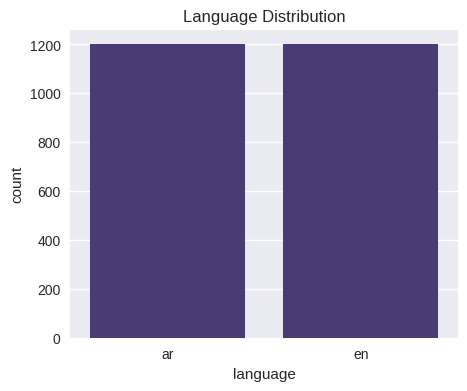

/tmp/ipython-input-1870852585.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(reshaped_labels, fontfamily='Arial')


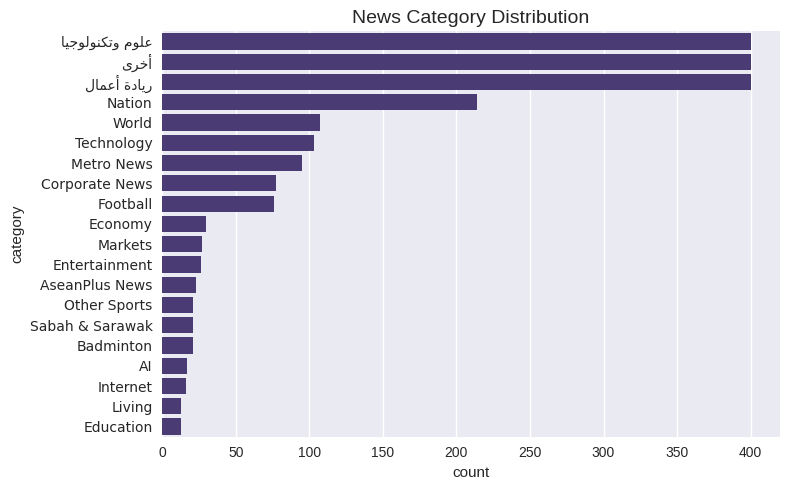

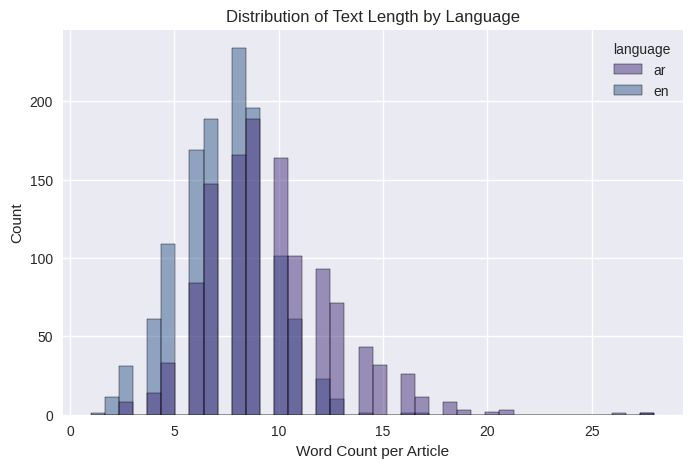

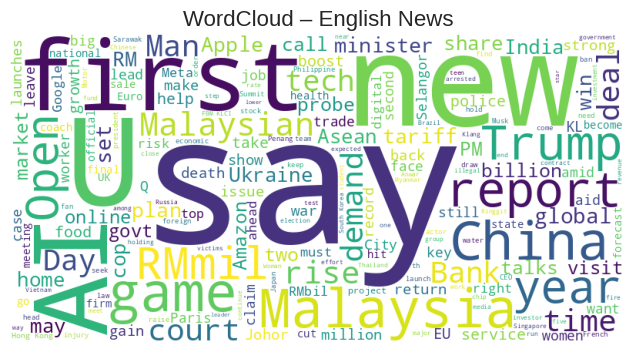

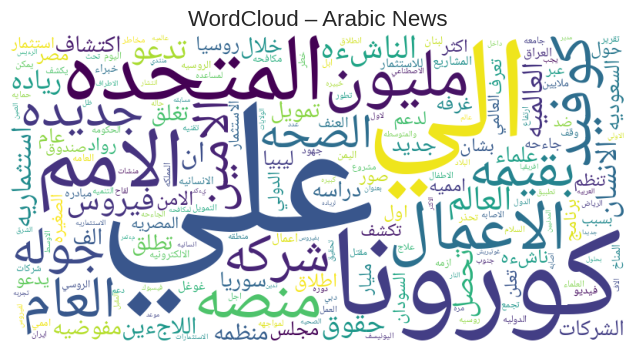

In [7]:
# ✅ Install required packages
!pip install arabic-reshaper python-bidi wordcloud --quiet

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import re
import pandas as pd


print('Number of Articles:', len(df))
print('\nMissing Values per Column:')
print(df.isnull().sum())


plt.figure(figsize=(5,4))
sns.countplot(x='language', data=df)
plt.title('Language Distribution')
plt.show()


# If some categories are in Arabic, reshape + reorder labels properly
categories = df['category'].value_counts().index[:20]

# Reshape Arabic text labels for y-axis
reshaped_labels = []
for cat in categories:
    try:
        if re.search(r'[\u0600-\u06FF]', cat):  # if Arabic characters exist
            reshaped_labels.append(get_display(arabic_reshaper.reshape(cat)))
        else:
            reshaped_labels.append(cat)
    except:
        reshaped_labels.append(cat)

plt.figure(figsize=(8,5))
sns.countplot(y='category', data=df, order=categories)
plt.title('News Category Distribution', fontsize=14)

# Fix Arabic label rendering
ax = plt.gca()
ax.set_yticklabels(reshaped_labels, fontfamily='Arial')
plt.tight_layout()
plt.show()


df['word_count'] = df['clean_text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='word_count', hue='language', bins=40)
plt.title('Distribution of Text Length by Language')
plt.xlabel('Word Count per Article')
plt.show()


# --- English WordCloud ---
text_en = ' '.join(df[df.language == 'en']['clean_text'].astype(str))
if len(text_en.strip()) > 0:
    wc_en = WordCloud(width=800, height=400, background_color='white').generate(text_en)
    plt.figure(figsize=(8,4))
    plt.imshow(wc_en)
    plt.axis('off')
    plt.title('WordCloud – English News', fontsize=16)
    plt.show()
else:
    print("⚠️ No English text found to generate a WordCloud.")

# Arabic WordCloud (connected & correct order)
text_ar = ' '.join(df[df.language == 'ar']['clean_text'])
text_ar = re.sub(r'[^؀-ۿ]+', ' ', text_ar)  # keep Arabic chars only

if len(text_ar.strip()) > 0:
    reshaped_text = arabic_reshaper.reshape(text_ar)

    # Download proper Arabic font
    !wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf -O NotoNaskhArabic-Regular.ttf

    wc_ar = WordCloud(
        font_path='NotoNaskhArabic-Regular.ttf',
        width=800,
        height=400,
        background_color='white',
        collocations=False
    ).generate(reshaped_text)

    plt.figure(figsize=(8,4))
    plt.imshow(wc_ar)
    plt.axis('off')
    plt.title('WordCloud – Arabic News', fontsize=16)
    plt.show()
else:
    print("⚠️ No Arabic text found to generate a WordCloud.")

## Step 7: Summary and Save Cleaned Data
In this final step, we summarize the key findings from the dataset and save the cleaned files for future NLP tasks.  

**Summary Includes:**
- Total number of news articles in both languages  
- Main categories represented in the dataset  
- Average article length (in words)  
- Confirmation of text cleaning steps applied  

Finally, we export two cleaned datasets — one for Arabic and one for English — back to Google Drive, ready for use in further analysis or model training.


In [8]:
print(f'''
DATA ANALYSIS SUMMARY:

• Dataset contains {len(df)} total news articles.
• Languages: Arabic & English.
• Major categories: {', '.join(df['category'].value_counts().index[:4])}.
• Average article length: {df['word_count'].mean():.1f} words.
• Cleaning removed punctuation, HTML, digits, and stopwords.
''')
df[df.language == 'ar'].to_csv('/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv', index=False, encoding='utf-8-sig')
df[df.language == 'en'].to_csv('/content/drive/MyDrive/NLP_Project/data/english_cleaned.csv', index=False, encoding='utf-8-sig')
print('Cleaned datasets saved successfully to Google Drive.')


DATA ANALYSIS SUMMARY:

• Dataset contains 2400 total news articles.
• Languages: Arabic & English.
• Major categories: علوم وتكنولوجيا, أخرى, ريادة أعمال, Nation.
• Average article length: 8.6 words.
• Cleaning removed punctuation, HTML, digits, and stopwords.

Cleaned datasets saved successfully to Google Drive.


## Deliverable 3: Tokenization, n‑gram LM (with perplexity), POS baseline, preliminary parsing


---



In [9]:
# Install libraries if needed
!pip install nltk scikit-learn --quiet

# Import libraries from D2
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# --- New libraries for D3 ---
import nltk
from nltk.util import ngrams
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import MLE  # Maximum Likelihood Estimation for LM
from nltk.tag import pos_tag
from nltk.chunk import RegexpParser
from nltk import word_tokenize, sent_tokenize
from sklearn.model_selection import train_test_split

# Download necessary NLTK data models
nltk.download('punkt')                 # For tokenization
nltk.download('averaged_perceptron_tagger_eng') # For POS tagging
nltk.download('maxent_ne_chunker')     # For chunking (used by RegexpParser)
nltk.download('words')                 # For chunking

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.


True

In [10]:


df_en_orig = pd.read_csv(english_path, encoding='utf-8-sig')
df_ar_orig = pd.read_csv(arabic_path, encoding='utf-8-sig')

df_en_orig = df_en_orig.dropna(subset=['Content'])
df_ar_orig = df_ar_orig.dropna(subset=['Content'])

print("Loaded original English data:")
display(df_en_orig[['title', 'Content']].head(2))

print("\nLoaded original Arabic data:")
display(df_ar_orig[['Title', 'Content']].head(2))


# --- 2. Load CLEANED text for n-gram Language Models ---
english_clean_path = '/content/drive/MyDrive/NLP_Project/data/english_cleaned.csv'
arabic_clean_path = '/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv'

df_en_clean = pd.read_csv(english_clean_path, encoding='utf-8-sig')
df_ar_clean = pd.read_csv(arabic_clean_path, encoding='utf-8-sig')

df_en_clean = df_en_clean.dropna(subset=['clean_text'])
df_ar_clean = df_ar_clean.dropna(subset=['clean_text'])


print("\nLoaded cleaned English data:")
display(df_en_clean[['text', 'clean_text']].head(2))

print("\nLoaded cleaned Arabic data:")
display(df_ar_clean[['text', 'clean_text']].head(2))

Loaded original English data:


,title,Content
0,Lower O&G prices could impact Budget 2026,PETALING JAYA: Budget 2026 may have to rely le...
1,APU research nets MCMC grant,INEFFICIENCIES have long posed a pressing logi...



Loaded original Arabic data:


,Title,Content
0,باحث امني يتمكن اختراق وسرقه سياره تيسلا 90 ثانيه,باستخدام معدات كلفته 300 دولار تمكن الباحث الا...
1,لماذا تثور البراكين بعنف عقود الخمول,تمكن العلماء اخيرا فهم المسءول الانفجارات العن...



Loaded cleaned English data:


,text,clean_text
0,Lower O&G prices could impact Budget 2026,Lower OG prices could impact Budget
1,APU research nets MCMC grant,APU research nets MCMC grant



Loaded cleaned Arabic data:


,text,clean_text
0,باحث امني يتمكن اختراق وسرقه سياره تيسلا 90 ثانيه,باحث امني يتمكن اختراق وسرقه سياره تيسلا ثانيه
1,لماذا تثور البراكين بعنف عقود الخمول,لماذا تثور البراكين بعنف عقود الخمول


##1.    Tokenization



In [11]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize
from google.colab import drive

# 0) Mount Drive
drive.mount('/content/drive', force_remount=False)

# 1) Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# 2) Paths
arabic_path  = '/content/drive/MyDrive/NLP_Project/data/Arabic_news.csv'
english_path = '/content/drive/MyDrive/NLP_Project/data/English_news.csv'

# 3) Load both datasets
ar_df = pd.read_csv(arabic_path,  encoding='utf-8-sig')
en_df = pd.read_csv(english_path, encoding='utf-8-sig')

# --- Auto rename English columns so they match Arabic structure ---
rename_map = {
    'title': 'Title',
    'Title': 'Title',
    'description': 'Content',
    'content': 'Content',
    'text': 'Content',
    'url': 'Link',
    'link': 'Link',
    'category': 'Category',
    'Category': 'Category'
}
en_df = en_df.rename(columns=rename_map)

# --- Keep only available columns ---
cols_keep = [c for c in ['Title', 'Content', 'Category'] if c in en_df.columns]
en_df = en_df[cols_keep].dropna(subset=['Content'])

# --- Arabic: keep same structure ---
ar_df = ar_df.rename(columns={'Title':'Title','Content':'Content','Category':'Category'})
ar_df = ar_df[['Title','Content','Category']].dropna(subset=['Content'])

# --- Add language column and combine ---
ar_df['language'] = 'ar'
en_df['language'] = 'en'
df = pd.concat([ar_df, en_df], ignore_index=True)

# --- Cleaning function ---
def clean_text(text, lang):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    if lang == 'en':
        sw = set(stopwords.words('english'))
        words = [w.lower() for w in text.split() if w.lower() not in sw]
    else:
        sw = set(stopwords.words('arabic'))
        words = [w for w in text.split() if w not in sw]
    return ' '.join(words)

# --- Apply cleaning ---
df['clean_text'] = df.apply(lambda x: clean_text(x['Content'], x['language']), axis=1)

# --- Save cleaned versions ---
ar_clean = df[df.language == 'ar'].copy()
en_clean = df[df.language == 'en'].copy()
ar_clean.to_csv('/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv', index=False, encoding='utf-8-sig')
en_clean.to_csv('/content/drive/MyDrive/NLP_Project/data/english_cleaned.csv', index=False, encoding='utf-8-sig')

print("✅ Saved cleaned files to Drive:")
print("- /content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv")
print("- /content/drive/MyDrive/NLP_Project/data/english_cleaned.csv")

# --- Reload cleaned files ---
arabic_clean_path  = '/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv'
english_clean_path = '/content/drive/MyDrive/NLP_Project/data/english_cleaned.csv'
df_ar_clean = pd.read_csv(arabic_clean_path,  encoding='utf-8-sig').dropna(subset=['clean_text'])
df_en_clean = pd.read_csv(english_clean_path, encoding='utf-8-sig').dropna(subset=['clean_text'])

# --- Tokenize only cleaned text ---
df_ar_clean['tokens'] = df_ar_clean['clean_text'].apply(lambda x: word_tokenize(str(x)))
df_en_clean['tokens'] = df_en_clean['clean_text'].apply(lambda x: word_tokenize(str(x)))

# --- Display samples ---
print("\n✅ Tokenized Cleaned English Text (head 5):")
display(df_en_clean[['Title', 'clean_text', 'tokens']].head(5))

print("\n✅ Tokenized Cleaned Arabic Text (head 5):")
display(df_ar_clean[['Title', 'clean_text', 'tokens']].head(5))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✅ Saved cleaned files to Drive:
- /content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv
- /content/drive/MyDrive/NLP_Project/data/english_cleaned.csv

✅ Tokenized Cleaned English Text (head 5):


,Title,clean_text,tokens
0,Lower O&G prices could impact Budget 2026,petaling jaya budget may rely less revenue cru...,"[petaling, jaya, budget, may, rely, less, reve..."
1,APU research nets MCMC grant,inefficiencies long posed pressing logistical ...,"[inefficiencies, long, posed, pressing, logist..."
2,Ensure infrastructure properly maintained,jalan skudai lama johor baru near kip mall tam...,"[jalan, skudai, lama, johor, baru, near, kip, ..."
3,"Copter tragedy: Funeral prayers, last respects...",ipoh funeral prayers final respects eight vict...,"[ipoh, funeral, prayers, final, respects, eigh..."
4,Putin says Russia will work with any elected U...,reuters president vladimir putin said remarks ...,"[reuters, president, vladimir, putin, said, re..."



✅ Tokenized Cleaned Arabic Text (head 5):


,Title,clean_text,tokens
0,باحث امني يتمكن اختراق وسرقه سياره تيسلا 90 ثانيه,باستخدام معدات كلفته تمكن الباحث الامني البلجي...,"[باستخدام, معدات, كلفته, تمكن, الباحث, الامني,..."
1,لماذا تثور البراكين بعنف عقود الخمول,تمكن العلماء اخيرا فهم المسءول الانفجارات العن...,"[تمكن, العلماء, اخيرا, فهم, المسءول, الانفجارا..."
2,لاجءو الروهينجا المنظمات الانسانيه تتاهب اكتشا...,وفي تصريحات صحفيه جنيف قال المتحدث باسم مفوضيه...,"[وفي, تصريحات, صحفيه, جنيف, قال, المتحدث, باسم..."
3,وزير التعليم العالي ايرينا بوكوفا مدير اليونسك...,قال الدكتور اشرف الشيحي وزير التعليم العالي وا...,"[قال, الدكتور, اشرف, الشيحي, وزير, التعليم, ال..."
4,الامم المتحده نامل ان يبرهن مءتمر برلين علي ال...,ويعد مءتمر برلين الدولي جزءا العمليه اطلقتها ا...,"[ويعد, مءتمر, برلين, الدولي, جزءا, العمليه, اط..."


##2.n-gram & average_perplexity

--- Trained an English 2-gram (Bigram) Laplace Language Model ---
English Vocabulary size: 25453
Average Perplexity on English Test Set (Laplace-smoothed): 11577.82

Generated English sample:
uk party allies inside ensure replicas popular turning area hiking activities

--- Trained an Arabic 2-gram (Bigram) Laplace Language Model ---
Arabic Vocabulary size: 47496
Average Perplexity on Arabic Test Set (Laplace-smoothed): 18552.83

Generated Arabic sample:
بن عبدالعزيز اعتماد الخدمات الدعم للباحثين عنها مستهدفات استراتيجيه دعونا نتعامل

📊 Language Model Comparison Table:


,Language,Average Perplexity
0,English,11577.819265
1,Arabic,18552.833134


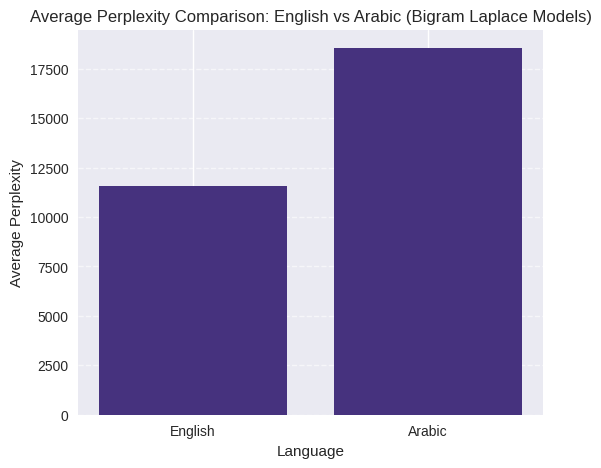

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.model_selection import train_test_split
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace  # add-1 smoothing




# Get tokenized cleaned English text as list of lists
tokens_en = df_en_clean['tokens'].tolist()

# Train/test split
train_tokens_en, test_tokens_en = train_test_split(tokens_en, test_size=0.2, random_state=42)

# Bigram
n = 2

# Prep training data
train_data_en, padded_vocab_en = padded_everygram_pipeline(n, train_tokens_en)

# Train Laplace bigram LM for English
lm_en = Laplace(n)
lm_en.fit(train_data_en, padded_vocab_en)

print(f"--- Trained an English {n}-gram (Bigram) Laplace Language Model ---")
print(f"English Vocabulary size: {len(lm_en.vocab)}")

# Evaluate perplexity on English test data
test_data_en, _ = padded_everygram_pipeline(n, test_tokens_en)

perplexities_en_list = []
for test_sent_ngrams in test_data_en:
    sent_list = list(test_sent_ngrams)
    if len(sent_list) > 0:
        perplexities_en_list.append(lm_en.perplexity(sent_list))

if len(perplexities_en_list) > 0:
    average_perplexity_en = sum(perplexities_en_list) / len(perplexities_en_list)
else:
    average_perplexity_en = float('nan')

print(f"Average Perplexity on English Test Set (Laplace-smoothed): {average_perplexity_en:.2f}")

# Sample English generation
seed_en = ['uk']  # pick a common English token
generated_tokens_en = lm_en.generate(10, text_seed=seed_en, random_seed=42)
generated_english_text = " ".join(seed_en + generated_tokens_en)

print("\nGenerated English sample:")
print(generated_english_text)



# Get tokenized cleaned Arabic text as list of lists
tokens_ar = df_ar_clean['tokens'].tolist()

# Train/test split
train_tokens_ar, test_tokens_ar = train_test_split(tokens_ar, test_size=0.2, random_state=42)

# Prep training data
train_data_ar, padded_vocab_ar = padded_everygram_pipeline(n, train_tokens_ar)

# Train Laplace bigram LM for Arabic
lm_ar = Laplace(n)
lm_ar.fit(train_data_ar, padded_vocab_ar)

print(f"\n--- Trained an Arabic {n}-gram (Bigram) Laplace Language Model ---")
print(f"Arabic Vocabulary size: {len(lm_ar.vocab)}")

# Evaluate perplexity on Arabic test data
test_data_ar, _ = padded_everygram_pipeline(n, test_tokens_ar)

perplexities_ar_list = []
for test_sent_ngrams in test_data_ar:
    sent_list = list(test_sent_ngrams)
    if len(sent_list) > 0:
        perplexities_ar_list.append(lm_ar.perplexity(sent_list))

if len(perplexities_ar_list) > 0:
    average_perplexity_ar = sum(perplexities_ar_list) / len(perplexities_ar_list)
else:
    average_perplexity_ar = float('nan')

print(f"Average Perplexity on Arabic Test Set (Laplace-smoothed): {average_perplexity_ar:.2f}")

# Sample Arabic generation
seed_ar = ['بن']  # pick a frequent Arabic token in your dataset
generated_tokens_ar = lm_ar.generate(10, text_seed=seed_ar, random_seed=42)
generated_arabic_text = " ".join(seed_ar + generated_tokens_ar)

print("\nGenerated Arabic sample:")
print(generated_arabic_text)




safe_en = average_perplexity_en if not math.isinf(average_perplexity_en) else float('nan')
safe_ar = average_perplexity_ar if not math.isinf(average_perplexity_ar) else float('nan')

df_compare = pd.DataFrame({
    'Language': ['English', 'Arabic'],
    'Average Perplexity': [safe_en, safe_ar]
})

print("\n📊 Language Model Comparison Table:")
display(df_compare)

plt.figure(figsize=(6,5))
plt.bar(df_compare['Language'], df_compare['Average Perplexity'])
plt.title('Average Perplexity Comparison: English vs Arabic (Bigram Laplace Models)')
plt.xlabel('Language')
plt.ylabel('Average Perplexity')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()



## 3. POS English

In [13]:
# POS TAGGING (English) - produces english_pos_tagged.csv
import nltk, pandas as pd
from nltk import word_tokenize, pos_tag
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger_eng")
# Optional chunker resources (not required here but harmless)
nltk.download("maxent_ne_chunker")
nltk.download("words")

# EDIT: path to your English CSV (must contain a Content column)
english_input = "/content/drive/MyDrive/NLP_Project/data/English_news.csv"
english_output = "/content/drive/MyDrive/NLP_Project/data/english_pos_tagged.csv"

df_en = pd.read_csv(english_input, encoding="utf-8-sig").dropna(subset=["Content"]).copy()

def tag_sentence_pos_en(text):
    tokens = word_tokenize(str(text))
    return pos_tag(tokens)   # returns list of (word, POS)

# Apply tagging (can take time for large files)
df_en["pos_tags"] = df_en["Content"].apply(tag_sentence_pos_en)
df_en["pos_only"] = df_en["pos_tags"].apply(lambda lst: [t for _, t in lst])

# Save result
df_en.to_csv(english_output, index=False, encoding="utf-8-sig")
print("Saved English POS-tagged file ->", english_output)
# Show a sample
display(df_en[['title', 'Content', 'pos_tags', 'pos_only']].head(10))



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


Saved English POS-tagged file -> /content/drive/MyDrive/NLP_Project/data/english_pos_tagged.csv


,title,Content,pos_tags,pos_only
0,Lower O&G prices could impact Budget 2026,PETALING JAYA: Budget 2026 may have to rely le...,"[(PETALING, NN), (JAYA, NN), (:, :), (Budget, ...","[NN, NN, :, VB, CD, MD, VB, TO, VB, JJR, IN, N..."
1,APU research nets MCMC grant,INEFFICIENCIES have long posed a pressing logi...,"[(INEFFICIENCIES, NNS), (have, VBP), (long, RB...","[NNS, VBP, RB, VBN, DT, VBG, JJ, NN, IN, DT, N..."
2,Ensure infrastructure properly maintained,"Jalan Skudai Lama in Johor Baru, near KIP Mall...","[(Jalan, NNP), (Skudai, NNP), (Lama, NNP), (in...","[NNP, NNP, NNP, IN, NNP, NNP, ,, IN, NNP, NNP,..."
3,"Copter tragedy: Funeral prayers, last respects...",IPOH: The funeral prayers and final respects f...,"[(IPOH, NN), (:, :), (The, DT), (funeral, JJ),...","[NN, :, DT, JJ, NNS, CC, JJ, NNS, IN, CD, NNS,..."
4,Putin says Russia will work with any elected U...,(Reuters) - President Vladimir Putin said in r...,"[((, (), (Reuters, NNPS), (), )), (-, :), (Pre...","[(, NNPS, ), :, NNP, NNP, NNP, VBD, IN, NNS, V..."
5,Alliance Bank focusing on gaining market share,"PETALING JAYA: Alliance Bank Malaysia Bhd , wh...","[(PETALING, NN), (JAYA, NN), (:, :), (Alliance...","[NN, NN, :, NNP, NNP, NNP, NNP, ,, WDT, VBD, D..."
6,Threads hits 175 million users on first annive...,"Threads, Meta's alternative to X (formerly Twi...","[(Threads, NNS), (,, ,), (Meta, NNP), ('s, POS...","[NNS, ,, NNP, POS, JJ, TO, NNP, (, RB, NNP, ),..."
7,Kerjaya Prospek secures RM11.36mil Andaman Isl...,KUALA LUMPUR: Kerjaya Prospek Group Bhd 's who...,"[(KUALA, NNP), (LUMPUR, NNP), (:, :), (Kerjaya...","[NNP, NNP, :, NNP, NNP, NNP, NNP, POS, JJ, NN,..."
8,Ice cream maker loses entire stock in blaze,"IPOH: A popular ice cream producer, which has ...","[(IPOH, NN), (:, :), (A, DT), (popular, JJ), (...","[NN, :, DT, JJ, NN, NN, NN, ,, WDT, VBZ, VBN, ..."
9,K-pop star Daesung from BigBang to hold first ...,"SINGAPORE: South Korean singer Daesung, a memb...","[(SINGAPORE, NN), (:, :), (South, JJ), (Korean...","[NN, :, JJ, JJ, NN, NNP, ,, DT, NN, IN, NNP, N..."


##4. POS Arabic

In [14]:
# POS TAGGING (Arabic, rule-based) - produces arabic_pos_tagged.csv
import re, pandas as pd
# EDIT: path to your Arabic CSV (must contain a Content column)
arabic_input = "/content/drive/MyDrive/NLP_Project/data/Arabic_news.csv"
arabic_output = "/content/drive/MyDrive/NLP_Project/data/arabic_pos_tagged.csv"

df_ar = pd.read_csv(arabic_input, encoding="utf-8-sig").dropna(subset=["Content"]).copy()

# Normalization and tokenization
def normalize_arabic(text):
    text = str(text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'[ًٌٍَُِّْ]', '', text)
    text = re.sub(r'[ء]', '', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    return text.strip()

def tokenize_arabic(text):
    return re.findall(r'[\u0600-\u06FF]+', str(text))

df_ar["Content"] = df_ar["Content"].apply(normalize_arabic)

# Basic closed-class lists (extend these for better performance)
CONJ_LIST = {"و", "او", "لكن", "ثم", "بل", "ف"}
PREP_LIST = {"في", "على", "من", "الى", "عن", "مع", "لدى", "حتى", "ب", "ل"}
PRON_LIST = {"هو", "هي", "هم", "هن", "انا", "نحن", "هذا", "هذه", "ذلك", "تلك", "انت", "انتم"}
VERB_LIST = {"كان", "تكون", "يكون", "كانت", "يكونون", "اصبح", "ظل", "قال", "قالت", "يقول", "يجب", "يمكن"}

def arabic_rule_pos(word):
    w = word
    if w in CONJ_LIST: return "CONJ"
    if w in PREP_LIST: return "P"
    if w in PRON_LIST: return "PRON"
    if w in VERB_LIST: return "VERB"
    if w.startswith("س") and len(w) > 2: return "VERB"
    if w.startswith(("و","ف")) and len(w)>2:
        root = w[1:]
        if root in VERB_LIST: return "VERB"
        if root in PREP_LIST: return "P"
        if root.startswith("ال"): return "N"
        return "CONJ"
    if w.startswith(("ب","ل")) and len(w)>2:
        root = w[1:]
        if root in VERB_LIST: return "VERB"
        if root.startswith("ال"): return "N"
        return "P"
    if w.startswith("ال") or w.endswith(("ة","ون","ين","ان")): return "N"
    if w.startswith(("ي","ت","ن")) or w.endswith(("وا","ت")): return "VERB"
    return "N"

def tag_sentence_pos_ar(text):
    tokens = tokenize_arabic(text)
    return [(tok, arabic_rule_pos(tok)) for tok in tokens]

df_ar["pos_tags_ar"] = df_ar["Content"].apply(tag_sentence_pos_ar)
df_ar["pos_only_ar"] = df_ar["pos_tags_ar"].apply(lambda lst: [t for _, t in lst])

# Save
df_ar.to_csv(arabic_output, index=False, encoding="utf-8-sig")
print("Saved Arabic POS-tagged file ->", arabic_output)
display(df_ar[['Title', 'Content', 'pos_tags_ar', 'pos_only_ar']].head(10))




Saved Arabic POS-tagged file -> /content/drive/MyDrive/NLP_Project/data/arabic_pos_tagged.csv


,Title,Content,pos_tags_ar,pos_only_ar
0,باحث امني يتمكن اختراق وسرقه سياره تيسلا 90 ثانيه,باستخدام معدات كلفته دولار تمكن الباحث الا...,"[(باستخدام, P), (معدات, VERB), (كلفته, N), (دو...","[P, VERB, N, N, VERB, N, N, N, P, CONJ, N, N, ..."
1,لماذا تثور البراكين بعنف عقود الخمول,تمكن العلما اخيرا فهم المسول الانفجارات العنيف...,"[(تمكن, VERB), (العلما, N), (اخيرا, N), (فهم, ...","[VERB, N, N, CONJ, N, N, N, P, N, P, N, CONJ, ..."
2,لاجءو الروهينجا المنظمات الانسانيه تتاهب اكتشا...,وفي تصريحات صحفيه جنيف قال المتحدث باسم مفوضيه...,"[(وفي, P), (تصريحات, VERB), (صحفيه, N), (جنيف,...","[P, VERB, N, N, VERB, N, P, N, N, N, N, P, N, ..."
3,وزير التعليم العالي ايرينا بوكوفا مدير اليونسك...,قال الدكتور اشرف الشيحي وزير التعليم العالي وا...,"[(قال, VERB), (الدكتور, N), (اشرف, N), (الشيحي...","[VERB, N, N, N, CONJ, N, N, N, N, N, N, N, P, ..."
4,الامم المتحده نامل ان يبرهن مءتمر برلين علي ال...,ويعد متمر برلين الدولي جزا العمليه اطلقتها الا...,"[(ويعد, CONJ), (متمر, N), (برلين, P), (الدولي,...","[CONJ, N, P, N, N, N, N, N, N, P, N, P, VERB, ..."
5,دراسه تحدد يمكنه التعافي كورونا علاج بالاكسجين,ونقلت وكاله يونهاب الكوريه ان الدراسه اجريت ال...,"[(ونقلت, CONJ), (وكاله, CONJ), (يونهاب, VERB),...","[CONJ, CONJ, VERB, N, N, N, VERB, N, N, N, N, ..."
6,منسق الامم المتحده لبنان يجب اختيار رءيس وزراء...,وكان كوبيش اجتمع صباح الثلاثا ريس الجمهوريه ال...,"[(وكان, VERB), (كوبيش, N), (اجتمع, N), (صباح, ...","[VERB, N, N, N, N, N, N, N, N, N, N, N, N, N, ..."
7,متي يجب التخلي العدسات اللاصقه الملونه,تسمح العدسات الملونه لاي شخص بالحصول علي لون ا...,"[(تسمح, VERB), (العدسات, N), (الملونه, N), (لا...","[VERB, N, N, P, N, N, N, P, N, N, P, VERB, N, ..."
8,تطبيقالموفر يتيح خصومات استثناءيه ل 300 علامه ...,ظل جاحه كورونا الراهنه يبحث العديد المتسوقين ح...,"[(ظل, VERB), (جاحه, N), (كورونا, N), (الراهنه,...","[VERB, N, N, N, VERB, N, N, N, N, CONJ, P, VER..."
9,ايران تنجح استنساخ صاروخ امريكي حديث,نجحت ايران استنساخ صاروخ الام...,"[(نجحت, VERB), (ايران, N), (استنساخ, N), (صارو...","[VERB, N, N, N, N, N, P, VERB, VERB, N, CONJ, ..."


##Part-of-Speech (POS) Tagging Analysis

/tmp/ipython-input-4284883905.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[t for t,_ in en_tags], y=[c for _,c in en_tags], ax=ax[0], palette="Blues_d")
/tmp/ipython-input-4284883905.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha="right")
/tmp/ipython-input-4284883905.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[t for t,_ in ar_tags], y=[c for _,c in ar_tags], ax=ax[1], palette="Greens_d")
/tmp/ipython-input-4284883905.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after se

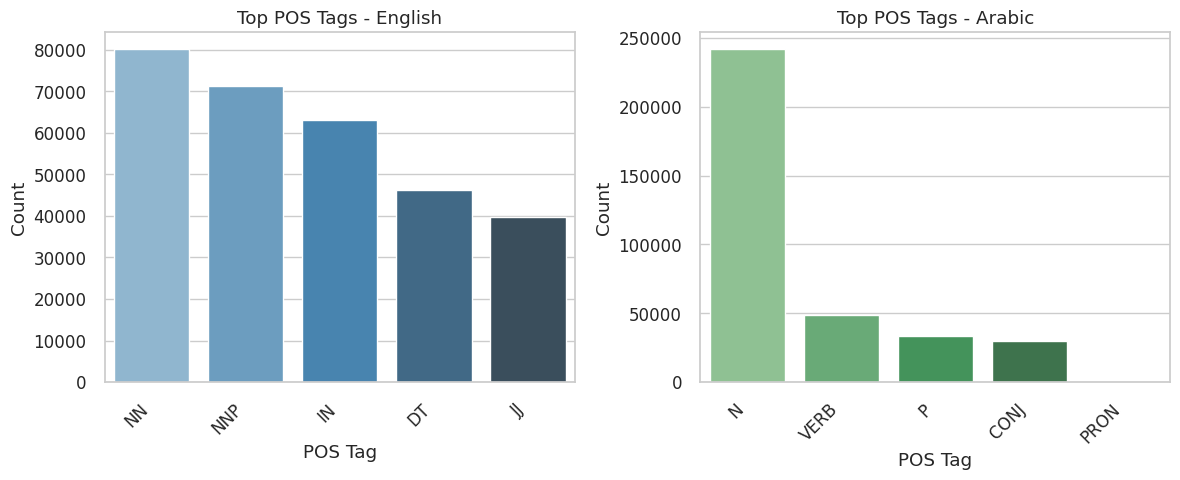

Top POS Tags (English): [('NN', 80244), ('NNP', 71221), ('IN', 63177), ('DT', 46177), ('JJ', 39605)]
Top POS Tags (Arabic): [('N', 242231), ('VERB', 48934), ('P', 33335), ('CONJ', 29593), ('PRON', 49)]

Average POS tags per sentence → English: 483.11 | Arabic: 295.12


In [15]:
# ===== Two POS Visualizations: Top Tags & Avg Tags per Sentence =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

sns.set(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (8,5)

# --- Helper functions ---
def safe_eval(x):
    try:
        return ast.literal_eval(str(x))
    except Exception:
        return []

def find_pos_col(df):
    for c in df.columns:
        if "pos" in c.lower() or "tag" in c.lower():
            return c
    return df.columns[0]

def pos_stats(path):
    df = pd.read_csv(path, encoding="utf-8-sig")
    col = find_pos_col(df)
    total_tags, tag_counter = 0, Counter()
    for x in df[col]:
        pairs = safe_eval(x)
        if isinstance(pairs, list):
            total_tags += len(pairs)
            for _, tag in pairs:
                tag_counter[tag] += 1
    avg_tags = total_tags / len(df) if len(df) else 0
    return avg_tags, tag_counter.most_common(5)

# --- Load and compute stats ---
en_avg, en_tags = pos_stats("/content/drive/MyDrive/NLP_Project/data/english_pos_tagged.csv")
ar_avg, ar_tags = pos_stats("/content/drive/MyDrive/NLP_Project/data/arabic_pos_tagged.csv")

# --- 1️⃣ Visualization: Top POS Tags ---
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.barplot(x=[t for t,_ in en_tags], y=[c for _,c in en_tags], ax=ax[0], palette="Blues_d")
ax[0].set_title("Top POS Tags - English")
ax[0].set_xlabel("POS Tag")
ax[0].set_ylabel("Count")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45, ha="right")

sns.barplot(x=[t for t,_ in ar_tags], y=[c for _,c in ar_tags], ax=ax[1], palette="Greens_d")
ax[1].set_title("Top POS Tags - Arabic")
ax[1].set_xlabel("POS Tag")
ax[1].set_ylabel("Count")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()



# --- Summary Printout ---
print(f"Top POS Tags (English): {en_tags}")
print(f"Top POS Tags (Arabic): {ar_tags}")
print(f"\nAverage POS tags per sentence → English: {en_avg:.2f} | Arabic: {ar_avg:.2f}")

##Parsing / Chunking (shallow NP/VP chunks)

In [16]:
# ENGLISH CHUNKING (NP/VP) + EVALUATION - reads english_pos_tagged.csv
import pandas as pd, ast
import nltk
from nltk import RegexpParser
from nltk.corpus import conll2000
from collections import Counter
nltk.download('conll2000', quiet=True)

# Paths
en_pos_path = "/content/drive/MyDrive/NLP_Project/data/english_pos_tagged.csv"
en_chunks_out = "/content/drive/MyDrive/NLP_Project/data/english_chunks_improved.csv"

# Load
en_pos = pd.read_csv(en_pos_path, encoding='utf-8-sig')
en_pos['pos_tags'] = en_pos['pos_tags'].apply(ast.literal_eval)

# Improved grammar
grammar_en_improved = r"""
    NP: {<DT|PRP\$>?<JJ.*>*<NN.*>+}
    VP: {<MD>?<VB.*><RB.*|JJ.*|NN.*|IN|DT|PRP\$>*}
"""
chunker_en = RegexpParser(grammar_en_improved)

def extract_chunks_en(tagged):
    tree = chunker_en.parse(tagged)
    nps, vps = [], []
    for st in tree.subtrees():
        if st.label()=='NP': nps.append(" ".join(w for w,t in st.leaves()))
        if st.label()=='VP': vps.append(" ".join(w for w,t in st.leaves()))
    return nps, vps

# Apply to file
en_pos[['NPs','VPs']] = en_pos['pos_tags'].apply(lambda t: pd.Series(extract_chunks_en(t)))
en_pos.to_csv(en_chunks_out, index=False, encoding='utf-8-sig')
print("Saved English chunks ->", en_chunks_out)

# Evaluate on CoNLL-2000 test
test_trees = conll2000.chunked_sents('test.txt')

def tree_to_spans(tree):
    spans = set()
    pos = 0
    for subtree in tree:
        if isinstance(subtree, nltk.Tree):
            length = len(subtree.leaves())
            spans.add((pos, pos+length, subtree.label()))
            pos += length
        else:
            pos += 1
    return spans

def predicted_tree_to_spans(sent, parser):
    parsed = parser.parse(sent)
    return tree_to_spans(parsed)

agg = Counter()
total_gold_spans = 0
for gold_tree in test_trees:
    sent = list(gold_tree.leaves())
    gold_spans = tree_to_spans(gold_tree)
    pred_spans = predicted_tree_to_spans(sent, chunker_en)
    tp = len(pred_spans & gold_spans)
    fp = len(pred_spans - gold_spans)
    fn = len(gold_spans - pred_spans)
    agg['tp'] += tp; agg['fp'] += fp; agg['fn'] += fn
    total_gold_spans += len(gold_spans)

tp, fp, fn = agg['tp'], agg['fp'], agg['fn']
precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
error_rate = (fp+fn)/total_gold_spans if total_gold_spans>0 else float('nan')
# After extracting NP/VP chunks into df_en[['NPs','VPs']]
# Ensure chunks exist
if 'NPs' not in df_en or 'VPs' not in df_en:
    from nltk import RegexpParser

    # Define grammar
    grammar_en_improved = r"""
        NP: {<DT|PRP\$>?<JJ.*>*<NN.*>+}
        VP: {<MD>?<VB.*><RB.*|JJ.*|NN.*|IN|DT|PRP\$>*}
    """
    chunker_en_improved = RegexpParser(grammar_en_improved)

    # Extract chunks function
    def extract_chunks(tagged):
        tree = chunker_en_improved.parse(tagged)
        nps, vps = [], []
        for st in tree.subtrees():
            if st.label()=='NP': nps.append(" ".join(w for w,t in st.leaves()))
            if st.label()=='VP': vps.append(" ".join(w for w,t in st.leaves()))
        return nps, vps

    # Apply chunking
    df_en[['NPs','VPs']] = df_en['pos_tags'].apply(lambda t: pd.Series(extract_chunks(t)))

# Now display only title + chunks
display(df_en[['title','Content', 'NPs','VPs']].head(10))



print("\n=== English evaluation (CoNLL-2000) ===")
print(f"Precision: {precision:.4f},\nRecall: {recall:.4f}, \nF1: {f1:.4f}, \nError-rate: {error_rate:.4f}")


Saved English chunks -> /content/drive/MyDrive/NLP_Project/data/english_chunks_improved.csv


,title,Content,NPs,VPs
0,Lower O&G prices could impact Budget 2026,PETALING JAYA: Budget 2026 may have to rely le...,"[PETALING JAYA, revenue, crude oil, natural ga...","[Budget, may have, rely less on, liquefied, ar..."
1,APU research nets MCMC grant,INEFFICIENCIES have long posed a pressing logi...,"[INEFFICIENCIES, logistical challenge, the cou...","[have long, posed a, pressing, accounts for ab..."
2,Ensure infrastructure properly maintained,"Jalan Skudai Lama in Johor Baru, near KIP Mall...","[Jalan Skudai Lama, Johor Baru, KIP Mall Tampo...","[is, filled with, is always wet, damaged even ..."
3,"Copter tragedy: Funeral prayers, last respects...",IPOH: The funeral prayers and final respects f...,"[IPOH, The funeral prayers, final respects, vi...","[were, carried, arrived at, following, being, ..."
4,Putin says Russia will work with any elected U...,(Reuters) - President Vladimir Putin said in r...,"[Reuters, President Vladimir Putin, remarks, W...","[said in, published on, does not, interfere in..."
5,Alliance Bank focusing on gaining market share,"PETALING JAYA: Alliance Bank Malaysia Bhd , wh...","[PETALING JAYA, Alliance Bank Malaysia Bhd, %,...","[posted a, ending, is, flagging, say, comes am..."
6,Threads hits 175 million users on first annive...,"Threads, Meta's alternative to X (formerly Twi...","[Threads, Meta, X, Twitter, monthly users, a y...","[has, hit, said, announcing, had, reached, hit..."
7,Kerjaya Prospek secures RM11.36mil Andaman Isl...,KUALA LUMPUR: Kerjaya Prospek Group Bhd 's who...,"[KUALA LUMPUR, Kerjaya Prospek Group Bhd, whol...","[has, accepted, valued at, associated, said, b..."
8,Ice cream maker loses entire stock in blaze,"IPOH: A popular ice cream producer, which has ...","[IPOH, A popular ice cream producer, local fol...","[has, served, lost all, broke, “, had, been, l..."
9,K-pop star Daesung from BigBang to hold first ...,"SINGAPORE: South Korean singer Daesung, a memb...","[SINGAPORE, South Korean singer Daesung, a mem...","[will be, holding, is, kicked, has, made, will..."



=== English evaluation (CoNLL-2000) ===
Precision: 0.5895,
Recall: 0.4578, 
F1: 0.5154, 
Error-rate: 0.8609


In [17]:
# === Evaluate English chunker on CoNLL-2000 ===
import nltk
from nltk import RegexpParser
from nltk.corpus import conll2000

# if you haven't downloaded the corpus yet, uncomment:
nltk.download('conll2000')

# Use your grammar_en if defined; otherwise define a similar grammar.
try:
    grammar = grammar_en  # uses the grammar you defined earlier
except NameError:
    grammar = r"""
      NP: {<DT|PRP\$>?<JJ.><NN.>+}
      VP: {<MD>?<VB.><RB.|JJ.|NN.>*}
    """

chunker = RegexpParser(grammar)

# load standard test set (we evaluate on both NP and VP if present in gold;
# conll2000 gold contains NP, CHUNK tags; limit chunk_types=None to use all types)
test_trees = conll2000.chunked_sents('test.txt')  # list of nltk.Tree (gold chunk trees)

# Evaluate using NLTK built-in evaluator (returns a ChunkScore object)
score = chunker.evaluate(test_trees)

# Print the human-readable summary (NLTK's ChunkScore has a nice str repr)
print("=== CoNLL-2000 evaluation (test.txt) using your RegexpParser ===")
print(score)   # this prints precision/recall/f1 for chunks found

# If you want explicit numeric values (precision/recall/f1) you can compute them
# by converting gold and predicted to span sets and counting TP/FP/FN.
from collections import Counter

def tree_to_spans(tree):
    """Return set of (start,end,label) spans from an nltk chunk tree.
       start/end are token indexes in the sentence (end exclusive)."""
    spans = set()
    pos = 0
    for subtree in tree:
        if isinstance(subtree, nltk.Tree):
            length = len(subtree.leaves())
            spans.add((pos, pos+length, subtree.label()))
            pos += length
        else:
            pos += 1
    return spans

def predicted_tree_to_spans(sent, parser):
    """Parse a sentence (list of (word,pos)) and return predicted spans as (start,end,label)."""
    parsed = parser.parse(sent)
    return tree_to_spans(parsed)

# Iterate through test set, compute aggregate TP/FP/FN (span-level, label-aware)
agg = Counter()
total_gold_spans = 0
for gold_tree in test_trees:
    sent = list(gold_tree.leaves())  # [(word,pos), ...]
    gold_spans = tree_to_spans(gold_tree)
    pred_spans = predicted_tree_to_spans(sent, chunker)
    # we compare label-aware exact spans (start,end,label)
    tp = len(pred_spans & gold_spans)
    fp = len(pred_spans - gold_spans)
    fn = len(gold_spans - pred_spans)
    agg['tp'] += tp; agg['fp'] += fp; agg['fn'] += fn
    total_gold_spans += len(gold_spans)

tp, fp, fn = agg['tp'], agg['fp'], agg['fn']
precision = tp/(tp+fp) if (tp+fp)>0 else 0.0
recall = tp/(tp+fn) if (tp+fn)>0 else 0.0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0.0
error_rate = (fp+fn)/total_gold_spans if total_gold_spans>0 else float('nan')

print("\n=== Numeric aggregate (label-aware exact-span) ===")
print(f"Total gold chunks: {total_gold_spans}")
print(f"TP: {tp}, FP: {fp}, FN: {fn}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, Error-rate: {error_rate:.4f}")

# --- Show a few concrete mismatch examples for inspection (first 5) ---
print("\n=== Example mismatches (first 5 sentences where prediction != gold) ===")
mismatch_count = 0
for i, gold_tree in enumerate(test_trees):
    sent = list(gold_tree.leaves())
    gold_spans = tree_to_spans(gold_tree)
    pred_spans = predicted_tree_to_spans(sent, chunker)
    if gold_spans != pred_spans:
        # print sentence, gold spans, predicted spans
        words = [w for w,_ in sent]
        print(f"\n--- Sentence index {i} ---")
        print("Sentence:", " ".join(words))
        print("Gold spans:", sorted(gold_spans))
        print("Pred spans:", sorted(pred_spans))
        mismatch_count += 1
        if mismatch_count >= 5:
            break

print(f"\nShown {mismatch_count} mismatch examples. Inspect these to decide rule fixes.")

[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
/tmp/ipython-input-1606293750.py:25: DeprecationWarning: 
  Function evaluate() has been deprecated.  Use accuracy(gold)
  instead.
  score = chunker.evaluate(test_trees)


=== CoNLL-2000 evaluation (test.txt) using your RegexpParser ===
ChunkParse score:
    IOB Accuracy:  25.3%%
    Precision:     48.0%%
    Recall:        11.0%%
    F-Measure:     17.9%%

=== Numeric aggregate (label-aware exact-span) ===
Total gold chunks: 21891
TP: 2403, FP: 2601, FN: 19488
Precision: 0.4802, Recall: 0.1098, F1: 0.1787, Error-rate: 1.0090

=== Example mismatches (first 5 sentences where prediction != gold) ===

--- Sentence index 0 ---
Sentence: Rockwell International Corp. 's Tulsa unit said it signed a tentative agreement extending its contract with Boeing Co. to provide structural parts for Boeing 's 747 jetliners .
Gold spans: [(0, 3, 'NP'), (3, 6, 'NP'), (6, 7, 'VP'), (7, 8, 'NP'), (8, 9, 'VP'), (9, 12, 'NP'), (12, 13, 'VP'), (13, 15, 'NP'), (15, 16, 'PP'), (16, 18, 'NP'), (18, 20, 'VP'), (20, 22, 'NP'), (22, 23, 'PP'), (23, 24, 'NP'), (24, 27, 'NP')]
Pred spans: [(6, 7, 'VP'), (8, 9, 'VP'), (12, 13, 'VP')]

--- Sentence index 1 ---
Sentence: Rockwell said the a

In [18]:
!pip install conllu


In [19]:
# -------------------------------
# Arabic NP/VP Chunking + Evaluation
# -------------------------------

import pandas as pd
from nltk import RegexpParser
import ast
from IPython.display import display
from collections import Counter
from conllu import parse_incr
from nltk.chunk.util import tree2conlltags, conlltags2tree

# -------------------------------
# 1️⃣ Load Arabic POS-tagged file
# -------------------------------
arabic_pos_path = "/content/drive/MyDrive/NLP_Project/data/arabic_pos_tagged.csv"
arabic_chunks_out = "/content/drive/MyDrive/NLP_Project/data/arabic_chunks_improved.csv"
df_ar = pd.read_csv(arabic_pos_path, encoding="utf-8-sig")
df_ar['pos_tags_ar'] = df_ar['pos_tags_ar'].apply(ast.literal_eval)

# Map Arabic POS → Penn-style tags (for chunking)
def map_to_penn_ar(tagged):
    mapped=[]
    for w,t in tagged:
        if t=='N': mapped.append((w,'NN'))
        elif t=='VERB': mapped.append((w,'VB'))
        elif t=='P': mapped.append((w,'IN'))
        elif t=='CONJ': mapped.append((w,'CC'))
        elif t=='PRON': mapped.append((w,'PRP'))
        else: mapped.append((w,'NN'))
    return mapped

df_ar['pos_tags_penn'] = df_ar['pos_tags_ar'].apply(map_to_penn_ar)

# -------------------------------
# 2️⃣ Define NP/VP grammar
# -------------------------------
grammar_ar = r"""
    NP: {<DT|PRP>?<JJ>?<NN>+}
    VP: {<VB><NN|PRP|IN|JJ|RB|NNP>*}
"""
chunker_ar = RegexpParser(grammar_ar)

# -------------------------------
# 3️⃣ Extract NP/VP chunks
# -------------------------------
def extract_chunks_ar(tagged):
    mapped = map_to_penn_ar(tagged)
    tree = chunker_ar.parse(mapped)
    nps, vps = [], []
    for st in tree.subtrees():
        if st.label()=='NP': nps.append(" ".join(w for w,t in st.leaves()))
        if st.label()=='VP': vps.append(" ".join(w for w,t in st.leaves()))
    return nps, vps
# Apply to file

df_ar[['NPs','VPs']] = df_ar['pos_tags_ar'].apply(lambda t: pd.Series(extract_chunks_ar(t)))
en_pos.to_csv(arabic_chunks_out, index=False, encoding='utf-8-sig')
print("Saved arabic chunks ->", arabic_chunks_out)
# -------------------------------
# 4️⃣ Load Gold-standard Arabic chunks (UD-PADT test set)
# -------------------------------
ud_test_path = '/content/drive/MyDrive/NLP_Project/data/ar_padt-ud-test.conllu'
gold_trees_ar = []

with open(ud_test_path, 'r', encoding='utf-8') as f:
    for sentence in parse_incr(f):
        iob_tags = []
        for token in sentence:
            word = token['form']
            upos = token['upostag']
            if upos in ['NOUN','PROPN']: tag = 'NN'
            elif upos == 'VERB': tag = 'VB'
            elif upos == 'PRON': tag = 'PRP'
            elif upos == 'ADP': tag = 'IN'
            elif upos in ['CONJ','CCONJ']: tag = 'CC'
            else: tag = 'NN'
            if upos in ['NOUN','PROPN','PRON']: chunk_tag='B-NP'
            elif upos=='VERB': chunk_tag='B-VP'
            else: chunk_tag='O'
            iob_tags.append((word, tag, chunk_tag))
        tree = conlltags2tree(iob_tags)
        gold_trees_ar.append(tree)

# Predict chunks using rule-based chunker
pred_trees_ar = [chunker_ar.parse(tags) for tags in df_ar['pos_tags_penn']]

# Align predicted and gold trees
n = min(len(pred_trees_ar), len(gold_trees_ar))
gold_trees_ar = gold_trees_ar[:n]
pred_trees_ar = pred_trees_ar[:n]

# Flatten to IOB
gold_flat = [x for sent in [tree2conlltags(t) for t in gold_trees_ar] for x in sent]
pred_flat = [x for sent in [tree2conlltags(t) for t in pred_trees_ar] for x in sent]

# -------------------------------
# 5️⃣ Chunk evaluation
# -------------------------------
def get_chunks(flat_iob):
    chunks = []
    current_chunk = []
    current_label = None
    for word, pos, chunk_tag in flat_iob:
        if chunk_tag.startswith('B-'):
            if current_chunk:
                chunks.append((current_chunk[0], current_chunk[-1], current_label))
            current_chunk = [word]
            current_label = chunk_tag[2:]
        elif chunk_tag.startswith('I-') and current_label is not None:
            current_chunk.append(word)
        else:
            if current_chunk:
                chunks.append((current_chunk[0], current_chunk[-1], current_label))
            current_chunk = []
            current_label = None
    if current_chunk:
        chunks.append((current_chunk[0], current_chunk[-1], current_label))
    return chunks

gold_chunks = get_chunks(gold_flat)
pred_chunks = get_chunks(pred_flat)

gold_counter = Counter([tuple(c) for c in gold_chunks])
pred_counter = Counter([tuple(c) for c in pred_chunks])

TP = sum((gold_counter & pred_counter).values())
FP = sum((pred_counter - gold_counter).values())
FN = sum((gold_counter - pred_counter).values())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
error_rate = 1 - (TP / len(gold_chunks)) if len(gold_chunks) > 0 else float('nan')

print("\n=== Arabic Chunker Evaluation ===")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-score:  {f1*100:.2f}%")
print(f"Error rate: {error_rate*100:.2f}%")
print(f"Total gold chunks: {len(gold_chunks)}, TP: {TP}, FP: {FP}, FN: {FN}")

# -------------------------------
# 6️⃣ Display only Title + NP/VP chunks
# -------------------------------
display(df_ar[['Title' ,'Content','NPs','VPs']].head(10))


Saved arabic chunks -> /content/drive/MyDrive/NLP_Project/data/arabic_chunks_improved.csv

=== Arabic Chunker Evaluation ===
Precision: 3.52%
Recall:    19.87%
F1-score:  5.98%
Error rate: 80.13%
Total gold chunks: 12902, TP: 2564, FP: 70238, FN: 10338


,Title,Content,NPs,VPs
0,باحث امني يتمكن اختراق وسرقه سياره تيسلا 90 ثانيه,باستخدام معدات كلفته دولار تمكن الباحث الا...,"[كلفته دولار, الباحث الامني البلجيكي, استغلال ...","[معدات, تمكن, نظام, سيارات, تيسلا, سرقه, سياره..."
1,لماذا تثور البراكين بعنف عقود الخمول,تمكن العلما اخيرا فهم المسول الانفجارات العنيف...,"[العلما اخيرا, المسول الانفجارات العنيفه, الخا...","[تمكن, يلعبه, يسمي, تحديد, تلعب, ثورات بركانيه..."
2,لاجءو الروهينجا المنظمات الانسانيه تتاهب اكتشا...,وفي تصريحات صحفيه جنيف قال المتحدث باسم مفوضيه...,"[صحفيه جنيف, المتحدث, مفوضيه الامم المتحده الس...","[تصريحات, قال, توجها, يديرها, اخذت, عينات, نتي..."
3,وزير التعليم العالي ايرينا بوكوفا مدير اليونسك...,قال الدكتور اشرف الشيحي وزير التعليم العالي وا...,"[الدكتور اشرف الشيحي, التعليم العالي والبحث ال...","[قال, تشهد, وقال, ناب, تنظمها, توفير, يشجع, كت..."
4,الامم المتحده نامل ان يبرهن مءتمر برلين علي ال...,ويعد متمر برلين الدولي جزا العمليه اطلقتها الا...,"[متمر, الدولي جزا العمليه اطلقتها الامم المتحد...","[سياده, وقال, خطوات, سلامه, يحتاج, يبرهن, يقود..."
5,دراسه تحدد يمكنه التعافي كورونا علاج بالاكسجين,ونقلت وكاله يونهاب الكوريه ان الدراسه اجريت ال...,"[الكوريه ان الدراسه, المركز الطبي الوطني الكور...","[يونهاب, اجريت, يعاني, تسجيل, يوم, تقل, تزيد, ..."
6,منسق الامم المتحده لبنان يجب اختيار رءيس وزراء...,وكان كوبيش اجتمع صباح الثلاثا ريس الجمهوريه ال...,[كوبيش اجتمع صباح الثلاثا ريس الجمهوريه اللبنا...,"[وكان, تعليقه, نيابه, قال, ستتماشي, تطلعات, ست..."
7,متي يجب التخلي العدسات اللاصقه الملونه,تسمح العدسات الملونه لاي شخص بالحصول علي لون ا...,"[العدسات الملونه, شخص بالحصول علي, العين المطل...","[تسمح, يكون, نفس, يسبب, يجب, سبوتنيك, يوجد, عد..."
8,تطبيقالموفر يتيح خصومات استثناءيه ل 300 علامه ...,ظل جاحه كورونا الراهنه يبحث العديد المتسوقين ح...,"[جاحه كورونا الراهنه, العديد المتسوقين حلول اك...","[ظل, يبحث, تقليل, تكلفه, تقليل, عمليات, تعزيز,..."
9,ايران تنجح استنساخ صاروخ امريكي حديث,نجحت ايران استنساخ صاروخ الام...,"[ايران استنساخ صاروخ الامريكي المضاد, اباتشي, ...","[نجحت, تحمله, مروحيات, درونات, تسميه, يقام, وق..."


## POS Accurcy

In [20]:
import nltk

# Download required NLTK corpora
nltk.download('treebank')
nltk.download('punkt')   # for tokenization if needed


[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
import pandas as pd
import nltk
from nltk import word_tokenize, pos_tag, RegexpParser
from nltk.corpus import treebank, conll2000
import ast
from collections import Counter


# Ensure required resources are downloaded
nltk.download('treebank')
nltk.download('averaged_perceptron_tagger')


# -------------------------------
# English POS Accuracy Evaluation
# -------------------------------

# Use last 500 sentences from Treebank as "test set"
test_sents = treebank.sents()[-500:]
gold_tagged_sents = treebank.tagged_sents()[-500:]

# Flatten gold tags
gold_pos = [pos for sent in gold_tagged_sents for _, pos in sent]

# Predict POS using nltk.pos_tag on test sentences
pred_pos = []
for sent in test_sents:
    pred_pos.extend([t for _, t in nltk.pos_tag(sent)])

# Ensure lengths match for a fair comparison (though zip handles this implicitly)
min_len = min(len(gold_pos), len(pred_pos))
gold_pos = gold_pos[:min_len]
pred_pos = pred_pos[:min_len]

# Calculate accuracy
pos_accuracy = sum(g == p for g, p in zip(gold_pos, pred_pos)) / len(gold_pos)
print(f"✅ English POS Accuracy: {pos_accuracy*100:.2f}%")



# --- Arabic POS accuracy ---
gold_ar_pos = [pos for _, pos, _ in gold_flat]
pred_ar_pos = [pos for _, pos, _ in pred_flat]

min_len_ar = min(len(gold_ar_pos), len(pred_ar_pos))
gold_ar_pos = gold_ar_pos[:min_len_ar]
pred_ar_pos = pred_ar_pos[:min_len_ar]

pos_acc_ar = sum(g==p for g,p in zip(gold_ar_pos, pred_ar_pos)) / len(gold_ar_pos)
print(f"✅ Arabic POS Accuracy: {pos_acc_ar*100:.2f}%")

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Package treebank is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


✅ English POS Accuracy: 89.37%
✅ Arabic POS Accuracy: 50.44%


##Checkpoint (end-to-end run + interim report)

In [22]:
# Minimal “orchestrator” to confirm end-to-end succeeds
outputs = [
 '/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv',
 '/content/drive/MyDrive/NLP_Project/data/english_cleaned.csv',
 '/content/drive/MyDrive/NLP_Project/data/english_pos_tagged.csv',
 '/content/drive/MyDrive/NLP_Project/data/arabic_pos_tagged.csv',
 '/content/drive/MyDrive/NLP_Project/data/english_chunks.csv',
 '/content/drive/MyDrive/NLP_Project/data/arabic_chunks.csv'
]

import os, pandas as pd
report = []
for p in outputs:
    ok = os.path.exists(p)
    n = pd.read_csv(p, nrows=1, encoding='utf-8-sig').shape[0] if ok else 0
    report.append({'file': p, 'exists': ok, 'sample_rows': n})

pd.DataFrame(report).to_csv('/content/drive/MyDrive/NLP_Project/data/checkpoint_D3.csv',
                            index=False, encoding='utf-8-sig')
pd.DataFrame(report)

,file,exists,sample_rows
0,/content/drive/MyDrive/NLP_Project/data/arabic...,True,1
1,/content/drive/MyDrive/NLP_Project/data/englis...,True,1
2,/content/drive/MyDrive/NLP_Project/data/englis...,True,1
3,/content/drive/MyDrive/NLP_Project/data/arabic...,True,1
4,/content/drive/MyDrive/NLP_Project/data/englis...,False,0
5,/content/drive/MyDrive/NLP_Project/data/arabic...,False,0


##Evaluation Deep-Dive (metrics & ablations)

EN coverage  NP:100.00%  VP:100.00%
AR coverage  NP:100.00%  VP:100.00%


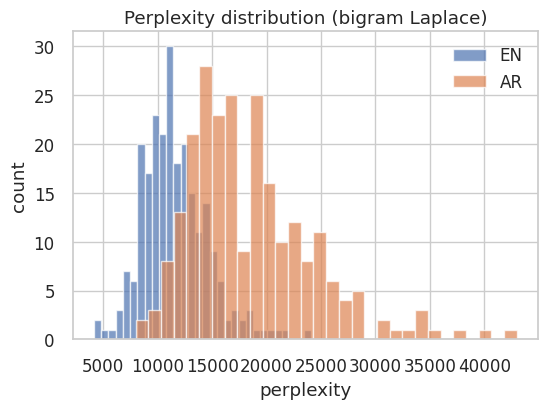

In [23]:
# 7A) Coverage metrics for chunking
import pandas as pd
en = pd.read_csv('/content/drive/MyDrive/NLP_Project/data/english_chunks_improved.csv', encoding='utf-8-sig')
ar = pd.read_csv('/content/drive/MyDrive/NLP_Project/data/arabic_chunks_improved.csv', encoding='utf-8-sig')

en_cov = (en['NPs'].str.len()>2).mean(), (en['VPs'].str.len()>2).mean()
ar_cov = (ar['NPs'].str.len()>2).mean(), (ar['VPs'].str.len()>2).mean()
print(f"EN coverage  NP:{en_cov[0]:.2%}  VP:{en_cov[1]:.2%}")
print(f"AR coverage  NP:{ar_cov[0]:.2%}  VP:{ar_cov[1]:.2%}")

# 7B) Perplexity distribution plot (English/Arabic)
import ast, matplotlib.pyplot as plt
from nltk.lm import Laplace
from nltk.lm.preprocessing import padded_everygram_pipeline
from sklearn.model_selection import train_test_split

def avg_ppx(tokens_list, n=2):
    train, test = train_test_split(tokens_list, test_size=0.2, random_state=42)
    train_data, vocab = padded_everygram_pipeline(n, train)
    lm = Laplace(n); lm.fit(train_data, vocab)
    test_data, _ = padded_everygram_pipeline(n, test)
    vals=[]
    for s in test_data:
        L=list(s)
        if L: vals.append(lm.perplexity(L))
    return vals

en_tok = pd.read_csv('/content/drive/MyDrive/NLP_Project/data/english_cleaned.csv', encoding='utf-8-sig')['clean_text'].dropna().apply(str.split).tolist()
ar_tok = pd.read_csv('/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv', encoding='utf-8-sig')['clean_text'].dropna().apply(str.split).tolist()

ppx_en = avg_ppx(en_tok); ppx_ar = avg_ppx(ar_tok)

plt.figure(figsize=(6,4)); plt.hist(ppx_en, bins=30, alpha=.7, label='EN'); plt.hist(ppx_ar, bins=30, alpha=.7, label='AR')
plt.title('Perplexity distribution (bigram Laplace)'); plt.legend(); plt.xlabel('perplexity'); plt.ylabel('count'); plt.show()

##NER / Information Extraction

In [24]:
import sys, subprocess, importlib, re
import pandas as pd
from IPython.display import display

def pip_install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)

# --- spaCy (English) ---
try: import spacy
except ImportError: pip_install(["spacy"]); import spacy
try: nlp_en = spacy.load("en_core_web_sm")
except Exception:
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    importlib.reload(spacy)
    nlp_en = spacy.load("en_core_web_sm")

# --- Hugging Face Transformers for Arabic NER ---
pip_install(["transformers", "torch"])
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

# Load a pre-trained Arabic NER model
try:
    ar_ner_tokenizer = AutoTokenizer.from_pretrained("CAMeL-Lab/bert-base-arabic-camelbert-mix-ner")
    ar_ner_model = AutoModelForTokenClassification.from_pretrained("CAMeL-Lab/bert-base-arabic-camelbert-mix-ner")
    # Fix: Add max_length and truncation to the pipeline initialization
    nlp_ar_hf = pipeline("ner", model=ar_ner_model, tokenizer=ar_ner_tokenizer, aggregation_strategy="simple", max_length=512, truncation=True)
    print("✅ Hugging Face Transformers Arabic NER model loaded.")
except Exception as e:
    print(f"⚠️ Failed to load Hugging Face Arabic NER model: {e}")
    print("Please check model name or internet connection.")
    nlp_ar_hf = None # Set to None if loading fails

# --- nltk optional ---
import nltk; nltk.download('punkt', quiet=True)

# ============================================================
# Ὄ1 Load Data (small sample for speed)
# ============================================================
english_path = "/content/drive/MyDrive/NLP_Project/data/English_news.csv"
arabic_path  = "/content/drive/MyDrive/NLP_Project/data/Arabic_news.csv"
out_dir      = "/content/drive/MyDrive/NLP_Project/data"

def normalize_arabic(text):
    """Normalize Alef variants, remove diacritics & trim spaces."""
    text = str(text)
    text = re.sub(r'[إأآا]', 'ا', text)    # Alef variants → ا
    text = re.sub(r'[ًٌٍَُِّْ]', '', text) # remove tashkeel
    text = re.sub(r'[ء]', '', text)        # remove Hamza
    text = re.sub(r'[^؀-ۿ\s]', ' ', text) # keep Arabic only
    return text.strip()

def load_csv_safely(path, text_candidates, title_candidates, default_title="Untitled", preprocessor=None):
    df = pd.read_csv(path, encoding="utf-8-sig")
    text_col = next((c for c in text_candidates if c in df.columns), None)
    if not text_col:
        raise ValueError(f"Missing expected text column in {path}")
    title_col = next((c for c in title_candidates if c in df.columns), None)
    if not title_col:
        df["title_tmp"] = df[text_col].astype(str).str.slice(0, 60)
        title_col = "title_tmp"

    if preprocessor:
        df[text_col] = df[text_col].apply(preprocessor)

    return df.dropna(subset=[text_col]).copy(), title_col, text_col

en_df, en_title_col, en_text_col = load_csv_safely(
    english_path, ["clean_text", "Content", "description", "text"], ["title", "Title"]
)
ar_df, ar_title_col, ar_text_col = load_csv_safely(
    arabic_path, ["clean_text", "Content", "text"], ["Title", "title"], "بدون عنوان",
    preprocessor=normalize_arabic
)

# limit for demo
en_df = en_df.head(20)
ar_df = ar_df.head(20)
print("✅ Data loaded:", len(en_df), "EN |", len(ar_df), "AR")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-mix-ner were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


⚠️ Failed to load Hugging Face Arabic NER model: TokenClassificationPipeline._sanitize_parameters() got an unexpected keyword argument 'max_length'
Please check model name or internet connection.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

✅ Data loaded: 20 EN | 20 AR


##English NER + Information Extraction

In [25]:
# ============================================================
# 🚀 English NER + IE (fast batch processing)
# ============================================================

texts_en = en_df[en_text_col].astype(str).tolist()
docs_en = list(nlp_en.pipe(texts_en, batch_size=8))

def extract_features_en(doc):
    ents = [(e.text, e.label_) for e in doc.ents]
    noun_chunks = [" ".join(t.text for t in chunk if t.is_alpha) for chunk in doc.noun_chunks]
    svos = []
    for sent in doc.sents:
        for tok in sent:
            if tok.pos_ == "VERB":
                subs = [w for w in tok.lefts if w.dep_ in ("nsubj","nsubjpass")]
                objs = [w for w in tok.rights if w.dep_ in ("dobj","attr","pobj")]
                if subs and objs:
                    svos.append((subs[0].text, tok.lemma_, objs[0].text))
    return ents, noun_chunks, svos

features = [extract_features_en(d) for d in docs_en]
en_df["entities"], en_df["noun_chunks"], en_df["svo_triples"] = zip(*features)

print("✅ English NER/IE complete.")
display(en_df[[en_title_col,"entities","noun_chunks","svo_triples"]].head(5))
en_df[[en_title_col,en_text_col,"entities","noun_chunks","svo_triples"]].to_csv(
    f"{out_dir}/english_ner_ie_fast.csv", index=False, encoding="utf-8-sig")


✅ English NER/IE complete.


,title,entities,noun_chunks,svo_triples
0,Lower O&G prices could impact Budget 2026,"[(2026, DATE), (LNG, ORG), (next year, DATE), ...","[PETALING JAYA, Budget, revenue, crude oil, th...","[(dividends, make, half), (income, raise, reve..."
1,APU research nets MCMC grant,"[(about 41%, PERCENT), (Lau Chee Yong, PERSON)...","[INEFFICIENCIES, a pressing logistical challen...","[(INEFFICIENCIES, pose, challenge), (delivery,..."
2,Ensure infrastructure properly maintained,"[(Jalan Skudai Lama, PERSON), (Johor Baru, GPE...","[Jalan Skudai Lama, Johor Baru, KIP Mall Tampo...","[(councils, fix, potholes)]"
3,"Copter tragedy: Funeral prayers, last respects...","[(eight, CARDINAL), (the Royal Malaysian Navy,...","[The funeral prayers, final respects, eight vi...","[(atmosphere, envelop, ceremony)]"
4,Putin says Russia will work with any elected U...,"[(Reuters, ORG), (Vladimir Putin, PERSON), (We...","[President Vladimir Putin, remarks, Wednesday,...","[(Putin, tell, media), (leader, launch, invasi..."


##🇸🇦 Arabic NER

In [26]:
# ============================================================
# Arabic NER using HuggingFace CAMeL-BERT (WORKING VERSION)
# ============================================================

!pip install transformers -q

from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline

MODEL_NAME = "CAMeL-Lab/bert-base-arabic-camelbert-msa-ner"

try:
    tokenizer_ar = AutoTokenizer.from_pretrained(MODEL_NAME)
    model_ar = AutoModelForTokenClassification.from_pretrained(MODEL_NAME)

    nlp_ar_hf = pipeline(
        "token-classification",
        model=model_ar,
        tokenizer=tokenizer_ar,
        grouped_entities=True
    )

    print("✅ Arabic CAMeL-BERT NER model loaded successfully")

except Exception as e:
    nlp_ar_hf = None
    print("❌ Failed to load Arabic HF model:", e)


# ------------------------------------------------------------
# Arabic NER function
# ------------------------------------------------------------
def ner_ar_fast(text):
    if nlp_ar_hf is None:
        return []

    if not isinstance(text, str) or text.strip() == "":
        return []

    try:
        output = nlp_ar_hf(text)
    except:
        return []

    return [(ent.get("word", ""), ent.get("entity_group", "")) for ent in output]


# ------------------------------------------------------------
# Apply to DataFrame
# ------------------------------------------------------------
ar_df["entities_ar"] = ar_df[ar_text_col].apply(ner_ar_fast)
display(ar_df[[ar_title_col, "entities_ar"]].head())


# ------------------------------------------------------------
# Save file
# ------------------------------------------------------------
save_path = f"{out_dir}/arabic_ner_fast.csv"
ar_df[[ar_title_col, ar_text_col, "entities_ar"]].to_csv(
    save_path, index=False, encoding="utf-8-sig"
)

print("✅ Arabic NER completed and saved to:", save_path)


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/980 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of the model checkpoint at CAMeL-Lab/bert-base-arabic-camelbert-msa-ner were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/token_classification.py:186: UserWarning: `grouped_entities` is deprecated and will be removed in version v5.0.0, defaulted to `aggregation_strategy="AggregationStrategy.SIMPLE"` instead.
  warnings.warn(
Asking to truncate to m

✅ Arabic CAMeL-BERT NER model loaded successfully


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

,Title,entities_ar
0,باحث امني يتمكن اختراق وسرقه سياره تيسلا 90 ثانيه,"[(دولار, MISC), (لينيرت واترز, PERS), (تيس, OR..."
1,لماذا تثور البراكين بعنف عقود الخمول,[]
2,لاجءو الروهينجا المنظمات الانسانيه تتاهب اكتشا...,[]
3,وزير التعليم العالي ايرينا بوكوفا مدير اليونسك...,"[(اشرف الشيحي, PERS), (ايرينا بوكوفا, PERS), (..."
4,الامم المتحده نامل ان يبرهن مءتمر برلين علي ال...,"[(برلين, LOC), (الامم المتحده, ORG), (ليبيا, L..."


✅ Arabic NER completed and saved to: /content/drive/MyDrive/NLP_Project/data/arabic_ner_fast.csv


### 📊 Entity Label Summary

In [27]:
import ast

# ============================================================
# ؠـ Summaries
# ============================================================

def summarize_entities(ent_lists, topk=8):
    counts = {}
    for row in ent_lists:
        for word, label in row:
            counts[label] = counts.get(label, 0) + 1
    ordered = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:topk]
    return pd.DataFrame(ordered, columns=["Label", "Count"])

# Reload en_df with 'entities' column, ensuring it's available
en_df_summary = pd.read_csv(f"{out_dir}/english_ner_ie_fast.csv", encoding="utf-8-sig")
en_df_summary["entities"] = en_df_summary["entities"].apply(ast.literal_eval)

print("\n=== English Entity Distribution ===")
display(summarize_entities(en_df_summary["entities"].tolist()))

# Reload ar_df with 'entities_ar' column, ensuring it's available
ar_df_summary = pd.read_csv(f"{out_dir}/arabic_ner_fast.csv", encoding="utf-8-sig")
ar_df_summary["entities_ar"] = ar_df_summary["entities_ar"].apply(ast.literal_eval)

print("\n=== Arabic Entity Distribution ===")
display(summarize_entities(ar_df_summary["entities_ar"].tolist()))


=== English Entity Distribution ===


,Label,Count
0,PERSON,196
1,ORG,192
2,DATE,168
3,GPE,94
4,CARDINAL,69
5,NORP,37
6,PERCENT,24
7,ORDINAL,20



=== Arabic Entity Distribution ===


,Label,Count
0,LOC,90
1,ORG,74
2,PERS,53
3,MISC,34


In [28]:
import pandas as pd
from collections import Counter

# --------------------------
# Load gold and prediction CSVs
# --------------------------
gold_path = "/content/drive/MyDrive/NLP_Project/data/english_ner_gold.csv"
pred_path = "/content/drive/MyDrive/NLP_Project/data/english_ner_ie_fast.csv"

gold_df = pd.read_csv(gold_path, encoding="utf-8-sig")
pred_df = pd.read_csv(pred_path, encoding="utf-8-sig")

# Convert entity strings to list of dicts
import ast

gold_entities = gold_df['entities'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
pred_entities = pred_df['entities'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])

# --------------------------
# Flatten entities into (text, label) tuples
# --------------------------
def flatten_entities(lst):
    """
    Flatten a list of entities into (text,label) tuples.
    Supports both dicts ({'text':..., 'label':...}) and tuples (text,label).
    """
    flat = []
    for e in lst:
        if isinstance(e, dict):
            flat.append((e.get('text',''), e.get('label','')))
        elif isinstance(e, (tuple, list)) and len(e) == 2:
            flat.append((e[0], e[1]))
    return flat

gold_flat = [tup for lst in gold_entities for tup in flatten_entities(lst)]
pred_flat = [tup for lst in pred_entities for tup in flatten_entities(lst)]

# --------------------------
# Overall performance
# --------------------------
gold_counter = Counter(gold_flat)
pred_counter = Counter(pred_flat)

TP = sum((gold_counter & pred_counter).values())
FP = sum((pred_counter - gold_counter).values())
FN = sum((gold_counter - pred_counter).values())

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("=== Overall NER Performance ===")
print(f"True Positives:  {TP}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")
print(f"F1-score:  {f1*100:.2f}%\n")

# --------------------------
# Per-entity type metrics
# --------------------------
entity_types = set([label for _, label in gold_flat])
print("=== Per Entity Type Performance ===")

for ent_type in sorted(entity_types):
    gold_type = [t for t in gold_flat if t[1] == ent_type]
    pred_type = [t for t in pred_flat if t[1] == ent_type]

    gold_counter_type = Counter(gold_type)
    pred_counter_type = Counter(pred_type)

    TP_type = sum((gold_counter_type & pred_counter_type).values())
    FP_type = sum((pred_counter_type - gold_counter_type).values())
    FN_type = sum((gold_counter_type - pred_counter_type).values())

    precision_type = TP_type / (TP_type + FP_type) if (TP_type + FP_type) > 0 else 0
    recall_type = TP_type / (TP_type + FN_type) if (TP_type + FN_type) > 0 else 0
    f1_type = 2 * precision_type * recall_type / (precision_type + recall_type) if (precision_type + recall_type) > 0 else 0

    print(f"{ent_type}: Precision={precision_type*100:.2f}% | Recall={recall_type*100:.2f}% | F1={f1_type*100:.2f}%")


=== Overall NER Performance ===
True Positives:  148
False Positives: 704
False Negatives: 36231
Precision: 17.37%
Recall:    0.41%
F1-score:  0.80%

=== Per Entity Type Performance ===
CARDINAL: Precision=21.74% | Recall=0.11% | F1=0.23%
DATE: Precision=22.02% | Recall=1.54% | F1=2.88%
GPE: Precision=20.21% | Recall=0.71% | F1=1.36%
ORG: Precision=0.00% | Recall=0.00% | F1=0.00%
PERSON: Precision=39.29% | Recall=0.43% | F1=0.85%


##Arabic Focus (normalization, clitics, light stemming; compare)

In [29]:
# Arabic normalization + clitic split + stemming
import re, pandas as pd
from nltk.stem.isri import ISRIStemmer
st = ISRIStemmer()

def normalize_ar(s):
    s = re.sub(r'[إأآا]', 'ا', str(s))
    s = re.sub(r'[ًٌٍَُِّْـ]', '', s)
    s = re.sub(r'[ء]', '', s)
    return s

def split_clitics(tok):
    # split common proclitics: و ف ب ل ك س
    m = re.match(r'^([وفبلكس])(.*)$', tok)
    return [m.group(1), m.group(2)] if m else [tok]

def light_stem(tokens):
    out=[]
    for t in tokens:
        parts=[]
        for p in split_clitics(t):
            parts.append(st.stem(p))
        out.extend(parts)
    return out

ar_clean = pd.read_csv('/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv', encoding='utf-8-sig')
ar_clean['clean_text_norm'] = ar_clean['clean_text'].apply(normalize_ar)
ar_clean['tokens_norm'] = ar_clean['clean_text_norm'].str.split()
ar_clean['tokens_norm_stem'] = ar_clean['tokens_norm'].apply(light_stem)

# Re-run LM perplexity (bigram Laplace) on improved tokens
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import Laplace
from sklearn.model_selection import train_test_split

def avg_ppx_tokens(tokens_list, n=2):
    train, test = train_test_split(tokens_list, test_size=0.2, random_state=42)
    tr, vocab = padded_everygram_pipeline(n, train)
    lm = Laplace(n); lm.fit(tr, vocab)
    te, _ = padded_everygram_pipeline(n, test)
    vals=[]
    for s in te:
        L=list(s)
        if L: vals.append(lm.perplexity(L))
    return sum(vals)/len(vals)

baseline_ppx = pd.read_csv('/content/drive/MyDrive/NLP_Project/data/arabic_cleaned.csv', encoding='utf-8-sig')['clean_text'].dropna().apply(str.split).tolist()
ppx_base = avg_ppx_tokens(baseline_ppx)
ppx_norm = avg_ppx_tokens(ar_clean['tokens_norm'].tolist())
ppx_norm_stem = avg_ppx_tokens(ar_clean['tokens_norm_stem'].tolist())

print(f"Arabic perplexity (baseline):     {ppx_base:.1f}")
print(f"Arabic perplexity (normalized):   {ppx_norm:.1f}")
print(f"Arabic perplexity (norm+stemmed): {ppx_norm_stem:.1f}")

ar_clean.to_csv('/content/drive/MyDrive/NLP_Project/data/arabic_clean_improved.csv', index=False, encoding='utf-8-sig')

Arabic perplexity (baseline):     18552.8
Arabic perplexity (normalized):   18460.2
Arabic perplexity (norm+stemmed): 1828.8
